## Simulating observational effects for synthetic Integral Field Spectroscopy (IFS) data
Beyond broadband imaging, GalSyn allows you to simulate realistic Integral Field Unit (IFU) observations. This process transforms idealized spectral cubes into mock observations by accounting for wavelength-dependent sensitivity, instrumental resolution, and spatial blurring.

In this example, we will simulate mock JWST NIRSpec IFU high-resolution data using the G140H/F070LP configuration. First, you must model the PSF cube for this specific disperser-filter combination. This can be done using the STPSF package; the procedures for this are available in the [STPSF documentation](https://stpsf.readthedocs.io/en/latest/jwst_ifu_datacubes.html#Simulating-IFU-mode-and-Datacubes).

### Preparing the standardized PSF data cube
The ``observe`` module requires a PSF cube where the wavelength axis matches your desired output grid. Since STPSF outputs multiple extensions, we first extract and standardize the ``DET_DIST`` data.

In [1]:
import numpy as np
from astropy.io import fits

# The PSF FITS file from STPSF package has multiple extensions. 
# We use the DET_DIST extension and store it in a single-extension file.
hdu = fits.open('psf_cube_G140H_F100LP.fits')
psf_cube_data = hdu['DET_DIST'].data

# Extract wavelength information for each slice in the PSF cube
cube_psf_wave_um = np.zeros(psf_cube_data.shape[0])
for i in range(psf_cube_data.shape[0]):
    cube_psf_wave_um[i] = hdu['det_dist'].header["WVLN%04d" % i] * 1e+6
hdu.close()

# Save as a standardized input for GalSyn
hdul = fits.HDUList()
hdul.append(fits.ImageHDU(data=psf_cube_data, name='psf_cube'))
hdul.writeto('psf_G140H_F100LP_standard.fits', overwrite=True)

### Configuring the IFU observation pipeline
The ``GalSynMockObservation_ifu`` module processes the data through a specific sequence designed for 3D spectroscopic data:
* Spectral Grid Alignment: The high-resolution synthetic cube is interpolated onto your ``desired_wave_grid``.
* Spatial Resampling: The cube is resampled to the ``final_pixel_scale_arcsec`` while maintaining flux conservation.
* Spectral Smoothing: Each spaxel is convolved along the wavelength axis with a Gaussian kernel to match the target instrumental resolution ($R$).
* Spatial PSF Convolution: The cube is convolved slice-by-slice using the 3D PSF cube to account for wavelength-dependent blurring.
* Noise Injection: Realistic, wavelength-dependent noise is injected independently into each slice.

Additional notes:
- Wavelength-dependent parameters: unlike imaging, parameters like ``limiting_magnitude`` and ``exposure_time`` can be provided as functions of wavelength to model instrument sensitivity variations accurately.
- Spectral smoothing: the module uses your ``spectral_resolution_R`` to derive the kernel width ($\sigma = \lambda / R / 2.355$) for each wavelength channel.

In [2]:
from scipy.interpolate import interp1d
from galsyn import GalSynMockObservation_ifu

fits_file_path = 'galsyn_39_107965_specphoto.fits'
desired_wave_grid = cube_psf_wave_um * 1e+4  # Convert microns to Angstroms
psf_cube_path = 'psf_G140H_F100LP_standard.fits'

# Observation parameters
psf_pixel_scale = 0.1
spectral_resolution_R = 2700
mag_zp = 28.0
exposure_time = 15000
final_pixel_scale_arcsec = 0.1

# Define a wavelength-dependent limiting magnitude function
limiting_magnitude_wave_func = interp1d([min(desired_wave_grid), max(desired_wave_grid)],
                                        [25.0, 24.5], fill_value="extrapolate")
snr_limit = 5.0

# Initialize and run the IFU pipeline
sifu = GalSynMockObservation_ifu(fits_file_path, desired_wave_grid, psf_cube_path, psf_pixel_scale,
                spectral_resolution_R, mag_zp, limiting_magnitude_wave_func, snr_limit,
                final_pixel_scale_arcsec, exposure_time)

sifu.process_datacube(dust_attenuation=True, apply_noise_to_cube=True)

# Save the final realistic IFU data cube
output_fits_path = 'obsifu_nirspec_g140h_f100lp_galsyn_39_107965_100mas.fits'
sifu.save_results_to_fits(output_fits_path)


Starting IFU Pipeline: Resample -> Smoothing -> PSF -> Noise
Processing IFU data for dust_attenuation=True
  Resampling spatially to 0.1000 arcsec (Bicubic)...
  Smoothing spectra to R=2700...
  Convolving each spatial slice with PSF...
  Simulating and injecting noise...
IFU results saved to obsifu_nirspec_g140h_f100lp_galsyn_39_107965_100mas.fits


### Check resulting data cube

In [3]:
cube = fits.open('obsifu_nirspec_g140h_f100lp_galsyn_39_107965_100mas.fits')
cube.info()

Filename: obsifu_nirspec_g140h_f100lp_galsyn_39_107965_100mas.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  SCI_DUST      1 ImageHDU        20   (104, 104, 4600)   float64   
  2  RMS_DUST      1 ImageHDU        20   (104, 104, 4600)   float64   
  3  WAVELENGTH_GRID    1 BinTableHDU     11   4600R x 1C   [D]   


In [4]:
cube[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
BUNIT   = 'erg/s/cm2/A'                                                         
PIXSIZE =                  0.1                                                  

physical scale of pixel: 0.8686865785764436 kpc


/var/folders/0s/b0mp8l31521cxfdgpf19xszm0000gn/T/ipykernel_13810/3897082873.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('inferno').copy()
/var/folders/0s/b0mp8l31521cxfdgpf19xszm0000gn/T/ipykernel_13810/3897082873.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('inferno').copy()


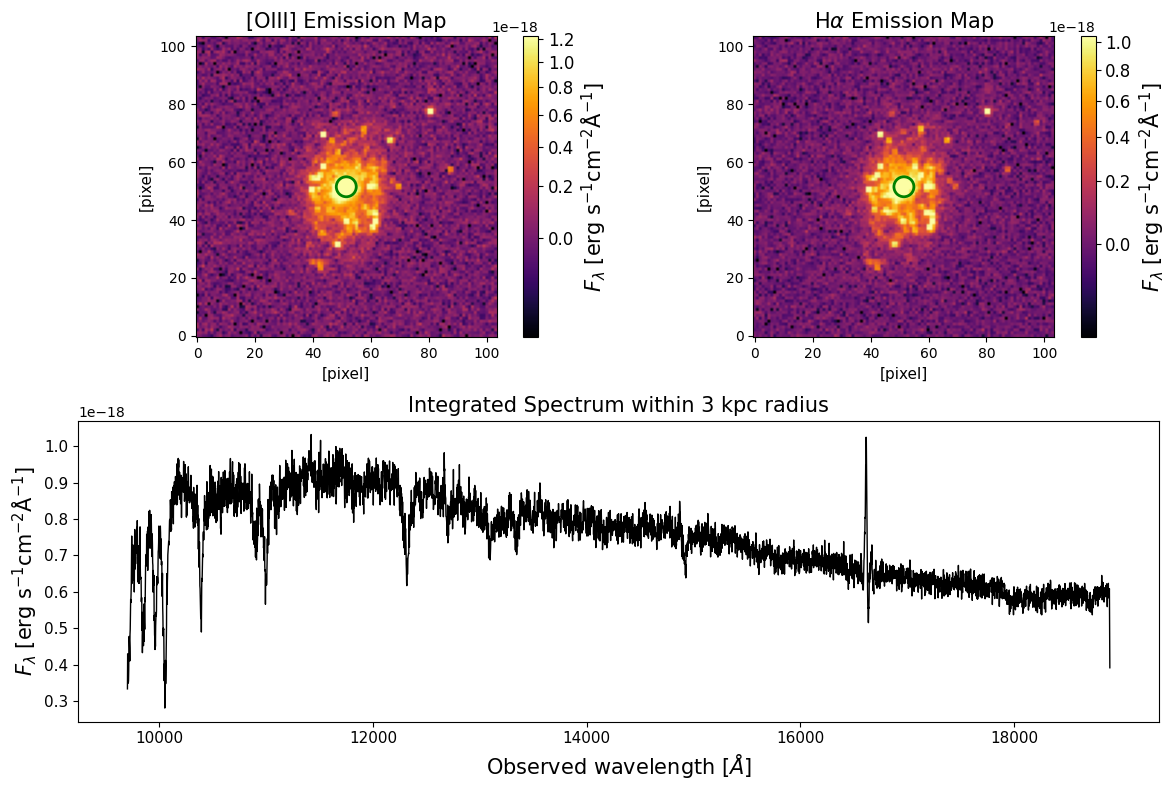

In [ ]:
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches 
import matplotlib.cm as cm 
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u

sci_data = cube['SCI_DUST'].data
wavelength = cube['WAVELENGTH_GRID'].data['WAVELENGTH']

# get physical scale of pixel in kpc
z = 1.531239    # redshift 
kpc_per_arcsec = 1.0 / cosmo.arcsec_per_kpc_proper(z).value
pix_kpc = cube[0].header['pixsize'] * kpc_per_arcsec
print (f'physical scale of pixel: {pix_kpc} kpc')
radius_kpc = 3.0
radius_pixels = radius_kpc / pix_kpc

# Select wavelength grids around the OIII and H-alpha lines
oiii_wave_range = [5007*(1.0+z)-200, 5007*(1.0+z)+200]
halpha_wave_range = [6564*(1.0+z)-200, 6564*(1.0+z)+200]
oiii_indices = np.where((wavelength >= oiii_wave_range[0]) & (wavelength <= oiii_wave_range[1]))[0]
halpha_indices = np.where((wavelength >= halpha_wave_range[0]) & (wavelength <= halpha_wave_range[1]))[0]

# Integrate to get the 2D maps
oiii_map = np.sum(sci_data[oiii_indices, :, :], axis=0)
halpha_map = np.sum(sci_data[halpha_indices, :, :], axis=0)

# Get the spatial dimensions
nz, ny, nx = sci_data.shape
center_x, center_y = (nx-1.0)/2.0, (ny-1.0)/2.0

# Create a circular mask
y, x = np.ogrid[:ny, :nx]
dist_from_center = np.sqrt((x - center_x)**2 + (y - center_y)**2)
mask = dist_from_center <= radius_pixels

# Create masked data cube
masked_sci_data0 = sci_data * mask

# Integrated spectrum
integrated_spectrum0 = np.sum(masked_sci_data0, axis=(1, 2))

# Create the multipanel plot
plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 2, width_ratios=[1, 1], height_ratios=[1, 1])

# OIII map
ax0 = plt.subplot(gs[0, 0])

cmap = cm.get_cmap('inferno').copy()
cmap.set_bad(color='black')
norm = simple_norm(oiii_map, 'sqrt', percent=98.5)
im0 = ax0.imshow(oiii_map, norm=norm, origin='lower', cmap=cmap)

ax0.set_title('[OIII] Emission Map', fontsize=15)
ax0.set_xlabel('[pixel]', fontsize=11)
ax0.set_ylabel('[pixel]', fontsize=11)
#plt.colorbar(im0, ax=ax0, label='Integrated Flux')

cbar = plt.colorbar(im0, ax=ax0)
cbar.set_label(r'$F_{\lambda}$ [erg $\rm{s}^{-1}\rm{cm}^{-2}\AA^{-1}$]', fontsize=15)
cbar.ax.tick_params(labelsize=12)

# New code to add circle to OIII map
circle0 = patches.Circle((center_x, center_y), radius_pixels, edgecolor='green', facecolor='none', linewidth=2)
ax0.add_patch(circle0)
# End of new code

# H-alpha map
ax1 = plt.subplot(gs[0, 1])

cmap = cm.get_cmap('inferno').copy()
cmap.set_bad(color='black')
norm = simple_norm(halpha_map, 'sqrt', percent=98.5)
im1 = ax1.imshow(halpha_map, norm=norm, origin='lower', cmap=cmap)

ax1.set_title(r'H$\alpha$ Emission Map', fontsize=15)
ax1.set_xlabel('[pixel]', fontsize=11)
ax1.set_ylabel('[pixel]', fontsize=11)

cbar = plt.colorbar(im1, ax=ax1)
cbar.set_label(r'$F_{\lambda}$ [erg $\rm{s}^{-1}\rm{cm}^{-2}\AA^{-1}$]', fontsize=15)
cbar.ax.tick_params(labelsize=12)

# New code to add circle to H-alpha map
circle1 = patches.Circle((center_x, center_y), radius_pixels, edgecolor='green', facecolor='none', linewidth=2)
ax1.add_patch(circle1)
# End of new code

# Integrated spectrum
ax2 = plt.subplot(gs[1, :])
ax2.plot(wavelength, integrated_spectrum0, lw=1, color='black')
ax2.set_title('Integrated Spectrum within 3 kpc radius', fontsize=15)
ax2.set_xlabel(r'Observed wavelength [$\AA$]', fontsize=15)
ax2.set_ylabel(r'$F_{\lambda}$ [erg $\rm{s}^{-1}\rm{cm}^{-2}\AA^{-1}$]', fontsize=15)
plt.setp(ax2.get_yticklabels(), fontsize=11)
plt.setp(ax2.get_xticklabels(), fontsize=11)

plt.tight_layout()